In [1]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pyvisa

ADDR = 'USB0::0x104D::0x1011::7A01020F12162064::RAW'

rm = pyvisa.ResourceManager()
print("resources:", rm.list_resources())   # confirm the wheel is listed

fw = rm.open_resource(ADDR)
fw.timeout = 2000  # ms

print("opened OK:", fw)
print("interface type:", fw.interface_type)
print("manufacturer:", fw.get_visa_attribute(pyvisa.constants.VI_ATTR_MANF_NAME))
print("model:", fw.get_visa_attribute(pyvisa.constants.VI_ATTR_MODEL_NAME))

fw.close()

resources: ('ASRL3::INSTR', 'ASRL4::INSTR')
opened OK: USBRaw at USB0::0x104D::0x1011::7A01020F12162064::0::RAW
interface type: 7
manufacturer: Newport Corporation
model: Universal Filter Wheel


In [14]:
from src.filterwheel.filterwheel import FilterWheelControl

ADDR = 'USB0::0x104D::0x1011::7A01020F12162064::RAW'

filter = FilterWheelControl(ADDR)
filter.get_position()

4

In [44]:
filter.set_position(3)

In [45]:
filter.close()

In [20]:
import serial.tools.list_ports
for port in serial.tools.list_ports.comports():
    print(port.device, port.description)

COM3 Intel(R) Active Management Technology - SOL (COM3)
COM4 Arduino Uno (COM4)


In [2]:
# Create camera sdk (ones!)
from src.pythorcam.thorcam import create_camera_sdk
camerasdk = create_camera_sdk()

Camera 29236 is connected
Camera 29236 is disconnected
0.3732607364654541


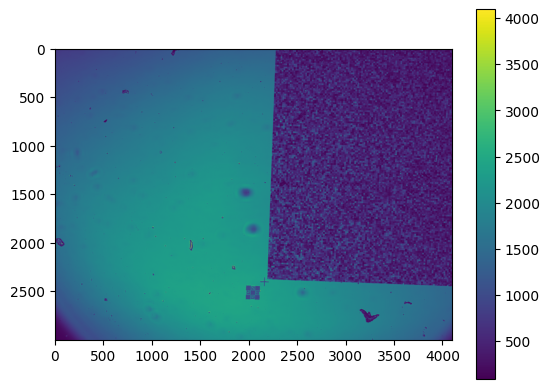

In [6]:
# Camera control
from src.pythorcam.thorcam import ThorlabsCamera

serial_number = '29236'
Camera = ThorlabsCamera(camerasdk, serial_number)
Camera.set_settings(exposure_time_us=300000, gain=0, black_level=5, bit_depth=np.uint16, out_bit_depth=np.float32)

Camera.arm()
time.sleep(0.1)

start = time.time()
image = Camera.get_image(num_frames_to_average=1)
end = time.time()

#Continuous_capturing_with_plt(Camera, zoom_value=0.4)

Camera.disarm()
Camera.close()
print(end - start)

plt.imshow(image)
plt.colorbar()

In [28]:
# Monochromator
from src.monochromator.mono import MonochromatorControl

MonochromatorControl.list_available_ports()

['COM4', 'COM3']

In [47]:
monochromator = MonochromatorControl(port='COM4')

Connected to COM4; you can now initialize the Monochromator.


In [48]:
monochromator.initialize_arduino()

INFO: monochromator initialized; send `home` to start


In [49]:
monochromator.home_motor()

INFO: homing
ADC: 288
OK: homed


In [50]:
monochromator.select_grating_mode(mode="VIS Grating")

OK: mode VIS


In [51]:
monochromator.set_wavelength(wavelength=600)

INFO: moving 600.00
OK: wavelength 600.00


In [52]:
monochromator.disconnect()

Disconnected from Arduino.


In [8]:
# Check motors movement 
from pylablib.devices import Thorlabs

mm = 1e-3

xshift = Thorlabs.KinesisMotor("27271460", scale='stage')
xshift.setup_velocity(max_velocity=0.1*mm)
xshift.setup_velocity(acceleration=0.05*mm)
xshift.move_by(-1*mm) # movement in m
xshift.wait_move()
xshift.close()